In [1]:
# Resolve project paths when launched from the root or a project subfolder.
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "trial_manifest.json").is_file() and (p / "analysis").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from the new G&P project folder or analysis folder.")
DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
# CELL 1 — Imports and correct file path

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = PROJECT_ROOT

FEATURE_FILE = RESULTS_DIR / "cycle_features_with_quality.csv"

print("Working directory:", ROOT)
print("Feature file:", FEATURE_FILE)
print("Feature file exists:", FEATURE_FILE.exists())

C:\Users\MSI\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Working directory: C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P
Feature file: C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P\results\cycle_features_with_quality.csv
Feature file exists: True


In [3]:
# CELL 2 — Load frozen cycle-level feature dataset

df = pd.read_csv(FEATURE_FILE)

print("Dataset shape:", df.shape)

print("\nCycles by person:")
print(
    df["person"]
    .value_counts()
    .sort_index()
)

print("\nCycle quality:")
print(
    df["cycle_quality"]
    .value_counts()
)

print("\nIndependent trials by person:")
print(
    df[["person", "trial"]]
    .drop_duplicates()
    .groupby("person")
    .size()
)

print("\nMissing values:", df.isna().sum().sum())

Dataset shape: (435, 97)

Cycles by person:
person
Buddhini     77
Harshika     59
Muthuni      30
Nadeera     124
Thenuri     145
Name: count, dtype: int64

Cycle quality:
cycle_quality
plausible           419
suspicious_short     14
suspicious_long       2
Name: count, dtype: int64

Independent trials by person:
person
Buddhini    6
Harshika    5
Muthuni     3
Nadeera     4
Thenuri     4
dtype: int64

Missing values: 0


In [4]:
# CELL 3 — Define metadata and model features

META_COLS = [
    "person",
    "trial",
    "phase",
    "cycle_index",
    "frames",
    "cycle_quality"
]

feature_cols = [
    col for col in df.columns
    if col not in META_COLS
]

print("Number of model features:", len(feature_cols))

print("\nModel features:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {col}")

assert len(feature_cols) == 91, (
    f"Expected 91 model features, but found {len(feature_cols)}"
)

assert "person" not in feature_cols
assert "trial" not in feature_cols
assert "phase" not in feature_cols
assert "cycle_index" not in feature_cols
assert "frames" not in feature_cols
assert "cycle_quality" not in feature_cols

print("\n✓ Feature definition passed.")

Number of model features: 91

Model features:
01. duration
02. left_ankle_to_foot_original_angle__mean
03. left_ankle_to_foot_original_angle__std
04. left_ankle_to_foot_original_angle__min
05. left_ankle_to_foot_original_angle__max
06. left_ankle_to_foot_original_angle__range
07. left_elbow_to_wrist_original_angle__mean
08. left_elbow_to_wrist_original_angle__std
09. left_elbow_to_wrist_original_angle__min
10. left_elbow_to_wrist_original_angle__max
11. left_elbow_to_wrist_original_angle__range
12. left_hip_to_knee_original_angle__mean
13. left_hip_to_knee_original_angle__std
14. left_hip_to_knee_original_angle__min
15. left_hip_to_knee_original_angle__max
16. left_hip_to_knee_original_angle__range
17. left_knee_to_ankle_original_angle__mean
18. left_knee_to_ankle_original_angle__std
19. left_knee_to_ankle_original_angle__min
20. left_knee_to_ankle_original_angle__max
21. left_knee_to_ankle_original_angle__range
22. left_shoulder_to_elbow_original_angle__mean
23. left_shoulder_to_elbow

In [5]:
# CELL 4 — Create independent trial/recording identifier

df["group_id"] = (
    df["person"].astype(str)
    + "_T"
    + df["trial"].astype(str)
)

trial_table = (
    df
    .groupby(
        ["person", "trial", "group_id"],
        as_index=False
    )
    .agg(
        cycles=("cycle_index", "size"),
        plausible_cycles=(
            "cycle_quality",
            lambda x: (x == "plausible").sum()
        )
    )
)

display(trial_table)

print("\nTotal independent recordings:", len(trial_table))

assert len(trial_table) == 22

print("✓ Found 22 independent person-trial recordings.")

,person,trial,group_id,cycles,plausible_cycles
0,Buddhini,1,Buddhini_T1,10,10
1,Buddhini,2,Buddhini_T2,15,7
2,Buddhini,3,Buddhini_T3,9,9
3,Buddhini,4,Buddhini_T4,9,9
4,Buddhini,7,Buddhini_T7,16,16
5,Buddhini,9,Buddhini_T9,18,16
6,Harshika,1,Harshika_T1,10,10
7,Harshika,2,Harshika_T2,21,19
8,Harshika,3,Harshika_T3,9,9
9,Harshika,4,Harshika_T4,10,10



Total independent recordings: 22
✓ Found 22 independent person-trial recordings.


In [6]:
# CELL 5 — Available independent trials for each person

trials_by_person = (
    trial_table
    .groupby("person")["trial"]
    .apply(lambda x: sorted(x.tolist()))
    .to_dict()
)

for person, trials in trials_by_person.items():
    print(f"{person:10s}: {trials}")

Buddhini  : [1, 2, 3, 4, 7, 9]
Harshika  : [1, 2, 3, 4, 5]
Muthuni   : [1, 2, 3]
Nadeera   : [1, 2, 3, 4]
Thenuri   : [1, 2, 3, 4]


In [7]:
# CELL 6 — Person-stratified held-out-trial folds

folds = [
    {
        "Buddhini": 1,
        "Harshika": 1,
        "Muthuni": 1,
        "Nadeera": 1,
        "Thenuri": 1,
    },

    {
        "Buddhini": 3,
        "Harshika": 3,
        "Muthuni": 2,
        "Nadeera": 2,
        "Thenuri": 2,
    },

    {
        "Buddhini": 4,
        "Harshika": 4,
        "Muthuni": 3,
        "Nadeera": 3,
        "Thenuri": 3,
    },
]

for fold_num, fold in enumerate(folds, start=1):

    print(f"\nFOLD {fold_num}")
    print("-" * 30)

    for person, trial in fold.items():
        print(f"{person:10s} -> Trial {trial}")


FOLD 1
------------------------------
Buddhini   -> Trial 1
Harshika   -> Trial 1
Muthuni    -> Trial 1
Nadeera    -> Trial 1
Thenuri    -> Trial 1

FOLD 2
------------------------------
Buddhini   -> Trial 3
Harshika   -> Trial 3
Muthuni    -> Trial 2
Nadeera    -> Trial 2
Thenuri    -> Trial 2

FOLD 3
------------------------------
Buddhini   -> Trial 4
Harshika   -> Trial 4
Muthuni    -> Trial 3
Nadeera    -> Trial 3
Thenuri    -> Trial 3


In [8]:
# CELL 7 — Validate requested held-out trials

available_pairs = set(
    zip(
        trial_table["person"],
        trial_table["trial"]
    )
)

for fold_num, fold in enumerate(folds, start=1):

    for person, trial in fold.items():

        assert (person, trial) in available_pairs, (
            f"Fold {fold_num}: "
            f"{person} Trial {trial} does not exist."
        )

print("✓ Every requested held-out trial exists.")

✓ Every requested held-out trial exists.


In [9]:
# CELL 8 — Build train/test splits without trial leakage

split_summary = []

for fold_num, held_out in enumerate(folds, start=1):

    test_mask = pd.Series(
        False,
        index=df.index
    )

    for person, trial in held_out.items():

        test_mask |= (
            (df["person"] == person)
            &
            (df["trial"] == trial)
        )

    train_df = df.loc[~test_mask].copy()
    test_df = df.loc[test_mask].copy()

    train_groups = set(train_df["group_id"])
    test_groups = set(test_df["group_id"])

    overlap = train_groups.intersection(test_groups)

    print("\n" + "=" * 55)
    print(f"FOLD {fold_num}")
    print("=" * 55)

    print("Training cycles:", len(train_df))
    print("Testing cycles: ", len(test_df))

    print("\nHeld-out trials:")

    display(
        test_df[
            ["person", "trial", "group_id"]
        ]
        .drop_duplicates()
        .sort_values(["person", "trial"])
        .reset_index(drop=True)
    )

    print("\nTest cycles by person:")

    print(
        test_df["person"]
        .value_counts()
        .sort_index()
    )

    print("\nTrain/test group overlap:", overlap)

    # Safety checks
    assert len(overlap) == 0

    assert set(test_df["person"]) == set(df["person"])

    assert set(train_df["person"]) == set(df["person"])

    split_summary.append({
        "fold": fold_num,
        "train_cycles": len(train_df),
        "test_cycles": len(test_df),
        "train_trials": train_df["group_id"].nunique(),
        "test_trials": test_df["group_id"].nunique(),
    })

print("\n✓ No independent trial appears in both train and test.")
print("✓ Every fold contains all five people.")


FOLD 1
Training cycles: 346
Testing cycles:  89

Held-out trials:


,person,trial,group_id
0,Buddhini,1,Buddhini_T1
1,Harshika,1,Harshika_T1
2,Muthuni,1,Muthuni_T1
3,Nadeera,1,Nadeera_T1
4,Thenuri,1,Thenuri_T1



Test cycles by person:
person
Buddhini    10
Harshika    10
Muthuni     10
Nadeera     20
Thenuri     39
Name: count, dtype: int64

Train/test group overlap: set()

FOLD 2
Training cycles: 346
Testing cycles:  89

Held-out trials:


,person,trial,group_id
0,Buddhini,3,Buddhini_T3
1,Harshika,3,Harshika_T3
2,Muthuni,2,Muthuni_T2
3,Nadeera,2,Nadeera_T2
4,Thenuri,2,Thenuri_T2



Test cycles by person:
person
Buddhini     9
Harshika     9
Muthuni      9
Nadeera     42
Thenuri     20
Name: count, dtype: int64

Train/test group overlap: set()

FOLD 3
Training cycles: 340
Testing cycles:  95

Held-out trials:


,person,trial,group_id
0,Buddhini,4,Buddhini_T4
1,Harshika,4,Harshika_T4
2,Muthuni,3,Muthuni_T3
3,Nadeera,3,Nadeera_T3
4,Thenuri,3,Thenuri_T3



Test cycles by person:
person
Buddhini     9
Harshika    10
Muthuni     11
Nadeera     21
Thenuri     44
Name: count, dtype: int64

Train/test group overlap: set()

✓ No independent trial appears in both train and test.
✓ Every fold contains all five people.


In [10]:
# CELL 9 — Evaluation split summary

split_summary_df = pd.DataFrame(split_summary)

display(split_summary_df)

print(
    "\nTotal test trials across the 3 folds:",
    split_summary_df["test_trials"].sum()
)

,fold,train_cycles,test_cycles,train_trials,test_trials
0,1,346,89,17,5
1,2,346,89,17,5
2,3,340,95,17,5



Total test trials across the 3 folds: 15


In [11]:
# CELL 10 — Final feature integrity check

X = df[feature_cols]

print("Feature matrix shape:", X.shape)

non_numeric = X.select_dtypes(
    exclude=[np.number]
).columns.tolist()

print("Non-numeric features:", non_numeric)

missing = X.isna().sum().sum()
infinite = np.isinf(X.to_numpy(dtype=float)).sum()

print("Missing feature values:", missing)
print("Infinite feature values:", infinite)

assert X.shape == (435, 91)
assert len(non_numeric) == 0
assert missing == 0
assert infinite == 0

print("\n✓ Feature matrix is ready for modelling.")

Feature matrix shape: (435, 91)
Non-numeric features: []


Missing feature values: 0
Infinite feature values: 0

✓ Feature matrix is ready for modelling.


In [12]:
# CELL 11 — Modelling imports

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("✓ Modelling tools imported.")

✓ Modelling tools imported.


In [13]:
# CELL 12 — Linear SVM baseline with trial-level separation

cycle_predictions = []
fold_metrics = []

for fold_num, held_out in enumerate(folds, start=1):

    # -----------------------------------
    # Construct held-out test set
    # -----------------------------------
    test_mask = pd.Series(False, index=df.index)

    for person, trial in held_out.items():
        test_mask |= (
            (df["person"] == person)
            & (df["trial"] == trial)
        )

    train_df = df.loc[~test_mask].copy()
    test_df = df.loc[test_mask].copy()

    # -----------------------------------
    # Features and labels
    # -----------------------------------
    X_train = train_df[feature_cols]
    y_train = train_df["person"]

    X_test = test_df[feature_cols]
    y_test = test_df["person"]

    # -----------------------------------
    # Pipeline
    # Scaler is fitted ONLY on training data
    # -----------------------------------
    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="linear",
                C=1.0,
                class_weight="balanced"
            )
        )
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # -----------------------------------
    # Cycle-level metrics
    # -----------------------------------
    acc = accuracy_score(y_test, y_pred)

    bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    fold_metrics.append({
        "fold": fold_num,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "test_cycles": len(test_df)
    })

    # Save individual predictions
    temp = test_df[
        [
            "person",
            "trial",
            "phase",
            "cycle_index",
            "group_id",
            "cycle_quality"
        ]
    ].copy()

    temp["fold"] = fold_num
    temp["predicted_person"] = y_pred

    cycle_predictions.append(temp)

    print(f"\nFOLD {fold_num}")
    print("-" * 40)
    print(f"Accuracy:          {acc:.3f}")
    print(f"Balanced accuracy: {bal_acc:.3f}")
    print(f"Macro F1:          {macro_f1:.3f}")


FOLD 1
----------------------------------------
Accuracy:          0.978
Balanced accuracy: 0.960
Macro F1:          0.963

FOLD 2
----------------------------------------
Accuracy:          0.978
Balanced accuracy: 0.990
Macro F1:          0.980

FOLD 3
----------------------------------------
Accuracy:          0.926
Balanced accuracy: 0.896
Macro F1:          0.878


In [14]:
# CELL 14 — Combine held-out cycle predictions

pred_df = pd.concat(
    cycle_predictions,
    ignore_index=True
)

print("Total held-out cycle predictions:", len(pred_df))

print("\nPredictions by true person:")
print(
    pred_df["person"]
    .value_counts()
    .sort_index()
)

print("\nOverall pooled cycle-level metrics")
print("-" * 40)

print(
    "Accuracy:",
    round(
        accuracy_score(
            pred_df["person"],
            pred_df["predicted_person"]
        ),
        3
    )
)

print(
    "Balanced accuracy:",
    round(
        balanced_accuracy_score(
            pred_df["person"],
            pred_df["predicted_person"]
        ),
        3
    )
)

print(
    "Macro F1:",
    round(
        f1_score(
            pred_df["person"],
            pred_df["predicted_person"],
            average="macro"
        ),
        3
    )
)

Total held-out cycle predictions: 273

Predictions by true person:
person
Buddhini     28
Harshika     29
Muthuni      30
Nadeera      83
Thenuri     103
Name: count, dtype: int64

Overall pooled cycle-level metrics
----------------------------------------
Accuracy: 0.96
Balanced accuracy: 0.944
Macro F1: 0.938


In [15]:
# CELL 15 — Classification report

people = sorted(df["person"].unique())

print(
    classification_report(
        pred_df["person"],
        pred_df["predicted_person"],
        labels=people,
        digits=3,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    Buddhini      0.871     0.964     0.915        28
    Harshika      0.879     1.000     0.935        29
     Muthuni      0.960     0.800     0.873        30
     Nadeera      0.988     0.976     0.982        83
     Thenuri      0.990     0.981     0.985       103

    accuracy                          0.960       273
   macro avg      0.938     0.944     0.938       273
weighted avg      0.962     0.960     0.959       273



,Buddhini,Harshika,Muthuni,Nadeera,Thenuri
Buddhini,27,1,0,0,0
Harshika,0,29,0,0,0
Muthuni,4,1,24,1,0
Nadeera,0,0,1,81,1
Thenuri,0,2,0,0,101


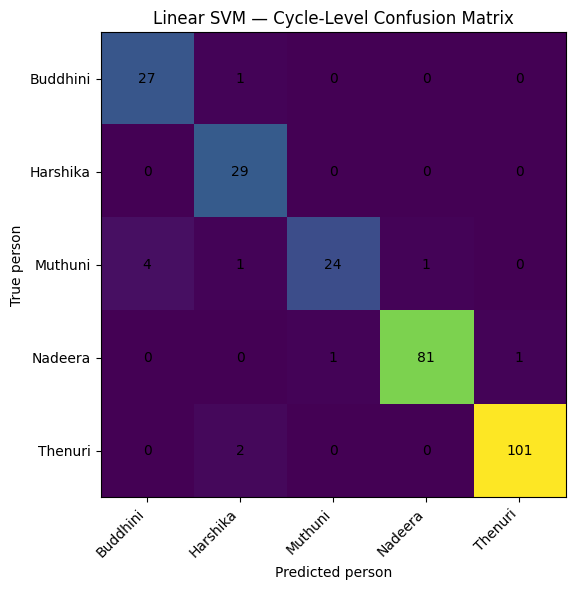

In [16]:
# CELL 16 — Cycle-level confusion matrix

import matplotlib.pyplot as plt
people = sorted(df["person"].unique())

cm = confusion_matrix(
    pred_df["person"],
    pred_df["predicted_person"],
    labels=people
)
cm_df = pd.DataFrame(
    cm,
    index=people,
    columns=people
)

display(cm_df)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(cm)

ax.set_xticks(range(len(people)))
ax.set_yticks(range(len(people)))

ax.set_xticklabels(
    people,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(people)

ax.set_xlabel("Predicted person")
ax.set_ylabel("True person")
ax.set_title(
    "Linear SVM — Cycle-Level Confusion Matrix"
)

for i in range(len(people)):
    for j in range(len(people)):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [17]:
# CELL 17 — Trial-level majority voting

def majority_vote(series):
    counts = series.value_counts()

    # deterministic tie handling
    winners = sorted(
        counts[counts == counts.max()].index.tolist()
    )

    return winners[0]


trial_predictions = (
    pred_df
    .groupby(
        ["fold", "person", "trial", "group_id"],
        as_index=False
    )
    .agg(
        n_cycles=("predicted_person", "size"),
        predicted_person=(
            "predicted_person",
            majority_vote
        )
    )
)

trial_predictions["correct"] = (
    trial_predictions["person"]
    ==
    trial_predictions["predicted_person"]
)

display(trial_predictions)

,fold,person,trial,group_id,n_cycles,predicted_person,correct
0,1,Buddhini,1,Buddhini_T1,10,Buddhini,True
1,1,Harshika,1,Harshika_T1,10,Harshika,True
2,1,Muthuni,1,Muthuni_T1,10,Muthuni,True
3,1,Nadeera,1,Nadeera_T1,20,Nadeera,True
4,1,Thenuri,1,Thenuri_T1,39,Thenuri,True
5,2,Buddhini,3,Buddhini_T3,9,Buddhini,True
6,2,Harshika,3,Harshika_T3,9,Harshika,True
7,2,Muthuni,2,Muthuni_T2,9,Muthuni,True
8,2,Nadeera,2,Nadeera_T2,42,Nadeera,True
9,2,Thenuri,2,Thenuri_T2,20,Thenuri,True


In [18]:
# CELL 18 — Trial-level evaluation

trial_accuracy = accuracy_score(
    trial_predictions["person"],
    trial_predictions["predicted_person"]
)

trial_balanced_accuracy = balanced_accuracy_score(
    trial_predictions["person"],
    trial_predictions["predicted_person"]
)

trial_macro_f1 = f1_score(
    trial_predictions["person"],
    trial_predictions["predicted_person"],
    average="macro"
)

print("TRIAL-LEVEL PERFORMANCE")
print("=" * 40)

print(
    f"Correct trials: "
    f"{trial_predictions['correct'].sum()} "
    f"/ {len(trial_predictions)}"
)

print(f"Accuracy:          {trial_accuracy:.3f}")
print(
    f"Balanced accuracy: "
    f"{trial_balanced_accuracy:.3f}"
)
print(f"Macro F1:          {trial_macro_f1:.3f}")

TRIAL-LEVEL PERFORMANCE
Correct trials: 15 / 15
Accuracy:          1.000
Balanced accuracy: 1.000
Macro F1:          1.000


In [19]:
# CELL 20 — Detailed vote distribution for each test trial

vote_table = (
    pred_df
    .groupby(
        [
            "fold",
            "person",
            "trial",
            "predicted_person"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

vote_table["total"] = vote_table.sum(axis=1)

display(vote_table)

predicted_person     Buddhini  Harshika  Muthuni  Nadeera  Thenuri  total
fold person   trial                                                      
1    Buddhini 1            10         0        0        0        0     10
     Harshika 1             0        10        0        0        0     10
     Muthuni  1             1         0        8        1        0     10
     Nadeera  1             0         0        0       20        0     20
     Thenuri  1             0         0        0        0       39     39
2    Buddhini 3             9         0        0        0        0      9
     Harshika 3             0         9        0        0        0      9
     Muthuni  2             0         0        9        0        0      9
     Nadeera  2             0         0        1       40        1     42
     Thenuri  2             0         0        0        0       20     20
3    Buddhini 4             8         1        0        0        0      9
     Harshika 4             0        10        0        0        0     10
     Muthuni  3             3         1        7        0        0     11
     Nadeera  3             0         0        0       21        0     21
     Thenuri  3             0         2        0        0       42     44

In [20]:
# CELL 21 — Generate exhaustive held-out-trial combinations

import itertools

people = sorted(trials_by_person.keys())

trial_lists = [
    trials_by_person[person]
    for person in people
]

all_holdout_combinations = list(
    itertools.product(*trial_lists)
)

print("People:", people)
print(
    "Number of held-out combinations:",
    len(all_holdout_combinations)
)

assert len(all_holdout_combinations) == 1440

print("\nFirst 5 combinations:")

for combo in all_holdout_combinations[:5]:
    print(dict(zip(people, combo)))

People: ['Buddhini', 'Harshika', 'Muthuni', 'Nadeera', 'Thenuri']
Number of held-out combinations: 1440

First 5 combinations:
{'Buddhini': 1, 'Harshika': 1, 'Muthuni': 1, 'Nadeera': 1, 'Thenuri': 1}
{'Buddhini': 1, 'Harshika': 1, 'Muthuni': 1, 'Nadeera': 1, 'Thenuri': 2}
{'Buddhini': 1, 'Harshika': 1, 'Muthuni': 1, 'Nadeera': 1, 'Thenuri': 3}
{'Buddhini': 1, 'Harshika': 1, 'Muthuni': 1, 'Nadeera': 1, 'Thenuri': 4}
{'Buddhini': 1, 'Harshika': 1, 'Muthuni': 1, 'Nadeera': 2, 'Thenuri': 1}


In [21]:
# CELL 22 — Exhaustive one-trial-per-person evaluation

exhaustive_results = []
exhaustive_trial_predictions = []

for split_id, combo in enumerate(
    all_holdout_combinations,
    start=1
):

    held_out = dict(zip(people, combo))

    test_mask = pd.Series(False, index=df.index)

    for person, trial in held_out.items():
        test_mask |= (
            (df["person"] == person)
            & (df["trial"] == trial)
        )

    train_df = df.loc[~test_mask].copy()
    test_df = df.loc[test_mask].copy()

    # Safety: no recording leakage
    assert set(train_df["group_id"]).isdisjoint(
        set(test_df["group_id"])
    )

    X_train = train_df[feature_cols]
    y_train = train_df["person"]

    X_test = test_df[feature_cols]
    y_test = test_df["person"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="linear",
                C=1.0,
                class_weight="balanced"
            )
        )
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # -----------------------------
    # Cycle-level metrics
    # -----------------------------

    exhaustive_results.append({
        "split_id": split_id,
        "accuracy": accuracy_score(
            y_test, y_pred
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_test, y_pred
            ),
        "macro_f1": f1_score(
            y_test,
            y_pred,
            average="macro"
        ),
        "test_cycles": len(test_df)
    })

    # -----------------------------
    # Trial-level predictions
    # -----------------------------

    temp = test_df[
        [
            "person",
            "trial",
            "group_id"
        ]
    ].copy()

    temp["predicted_person"] = y_pred

    for (
        true_person,
        trial,
        group_id
    ), group in temp.groupby(
        ["person", "trial", "group_id"]
    ):

        counts = (
            group["predicted_person"]
            .value_counts()
        )

        winners = sorted(
            counts[
                counts == counts.max()
            ].index.tolist()
        )

        predicted_person = winners[0]

        exhaustive_trial_predictions.append({
            "split_id": split_id,
            "person": true_person,
            "trial": trial,
            "group_id": group_id,
            "n_cycles": len(group),
            "predicted_person":
                predicted_person,
            "correct":
                predicted_person
                == true_person
        })

print("✓ Exhaustive evaluation complete.")
print(
    "Splits evaluated:",
    len(exhaustive_results)
)

print(
    "Trial predictions:",
    len(exhaustive_trial_predictions)
)

✓ Exhaustive evaluation complete.
Splits evaluated: 1440
Trial predictions: 7200


In [22]:
# CELL 23 — Exhaustive split performance

exhaustive_results_df = pd.DataFrame(
    exhaustive_results
)

display(
    exhaustive_results_df[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1"
        ]
    ]
    .describe()
    .round(3)
)

print("\nMEAN PERFORMANCE")
print("-" * 40)

print(
    "Accuracy:",
    round(
        exhaustive_results_df[
            "accuracy"
        ].mean(),
        3
    )
)

print(
    "Balanced accuracy:",
    round(
        exhaustive_results_df[
            "balanced_accuracy"
        ].mean(),
        3
    )
)

print(
    "Macro F1:",
    round(
        exhaustive_results_df[
            "macro_f1"
        ].mean(),
        3
    )
)

,accuracy,balanced_accuracy,macro_f1
count,1440.000,1440.000,1440.000
mean,0.964,0.950,0.948
std,0.022,0.032,0.032
min,0.850,0.794,0.788
25%,0.951,0.933,0.931
50%,0.966,0.951,0.954
75%,0.978,0.973,0.970
max,1.000,1.000,1.000



MEAN PERFORMANCE
----------------------------------------
Accuracy: 0.964
Balanced accuracy: 0.95
Macro F1: 0.948


In [23]:
# CELL 24 — Per-recording identification robustness

exhaustive_trial_df = pd.DataFrame(
    exhaustive_trial_predictions
)

trial_robustness = (
    exhaustive_trial_df
    .groupby(
        ["person", "trial", "group_id"],
        as_index=False
    )
    .agg(
        times_tested=("correct", "size"),
        times_correct=("correct", "sum"),
        correct_rate=("correct", "mean")
    )
)

trial_robustness["correct_pct"] = (
    100 * trial_robustness["correct_rate"]
)

display(
    trial_robustness[
        [
            "person",
            "trial",
            "times_tested",
            "times_correct",
            "correct_pct"
        ]
    ]
    .sort_values(
        ["person", "trial"]
    )
    .round(2)
)

,person,trial,times_tested,times_correct,correct_pct
0,Buddhini,1,240,240,100.00
1,Buddhini,2,240,240,100.00
2,Buddhini,3,240,240,100.00
3,Buddhini,4,240,240,100.00
4,Buddhini,7,240,233,97.08
5,Buddhini,9,240,240,100.00
6,Harshika,1,288,288,100.00
7,Harshika,2,288,288,100.00
8,Harshika,3,288,288,100.00
9,Harshika,4,288,288,100.00


In [24]:
# CELL 25 — Overall exhaustive trial-level results

overall_trial_correct = (
    exhaustive_trial_df["correct"].mean()
)

print("Repeated trial-level predictions:")
print(len(exhaustive_trial_df))

print(
    "\nOverall correct proportion:",
    f"{100 * overall_trial_correct:.2f}%"
)

print("\nPer-person correct proportion:")

person_trial_performance = (
    exhaustive_trial_df
    .groupby("person")["correct"]
    .agg(["count", "sum", "mean"])
)

person_trial_performance["correct_pct"] = (
    100 * person_trial_performance["mean"]
)

display(
    person_trial_performance.round(3)
)

Repeated trial-level predictions:
7200

Overall correct proportion: 99.90%

Per-person correct proportion:


,count,sum,mean,correct_pct
person,,,,
Buddhini,1440,1433,0.995,99.514
Harshika,1440,1440,1.000,100.000
Muthuni,1440,1440,1.000,100.000
Nadeera,1440,1440,1.000,100.000
Thenuri,1440,1440,1.000,100.000


In [25]:
# CELL 26 — Rank trials by identification robustness

display(
    trial_robustness[
        [
            "person",
            "trial",
            "times_tested",
            "times_correct",
            "correct_pct"
        ]
    ]
    .sort_values(
        "correct_pct",
        ascending=True
    )
    .reset_index(drop=True)
    .round(2)
)

,person,trial,times_tested,times_correct,correct_pct
0,Buddhini,7,240,233,97.08
1,Buddhini,1,240,240,100.00
2,Buddhini,3,240,240,100.00
3,Buddhini,2,240,240,100.00
4,Buddhini,4,240,240,100.00
5,Buddhini,9,240,240,100.00
6,Harshika,1,288,288,100.00
7,Harshika,2,288,288,100.00
8,Harshika,3,288,288,100.00
9,Harshika,4,288,288,100.00


In [26]:
# CELL 27 — Quality-filtered sensitivity dataset

df_clean = (
    df[df["cycle_quality"] == "plausible"]
    .copy()
    .reset_index(drop=True)
)

print("Original cycles:", len(df))
print("Filtered cycles:", len(df_clean))
print("Removed cycles:", len(df) - len(df_clean))

print("\nCycles by person:")
print(
    df_clean["person"]
    .value_counts()
    .sort_index()
)

print("\nTrials remaining:")
print(
    df_clean[["person", "trial"]]
    .drop_duplicates()
    .groupby("person")
    .size()
)

assert len(df_clean) == 419
assert df_clean["group_id"].nunique() == 22

print("\n✓ All 22 independent trials remain.")

Original cycles: 435
Filtered cycles: 419
Removed cycles: 16

Cycles by person:
person
Buddhini     67
Harshika     57
Muthuni      30
Nadeera     124
Thenuri     141
Name: count, dtype: int64

Trials remaining:
person
Buddhini    6
Harshika    5
Muthuni     3
Nadeera     4
Thenuri     4
dtype: int64

✓ All 22 independent trials remain.


In [27]:
# CELL 28 — Exhaustive evaluation on quality-filtered cycles

clean_results = []
clean_trial_predictions = []

for split_id, combo in enumerate(
    all_holdout_combinations,
    start=1
):

    held_out = dict(zip(people, combo))

    test_mask = pd.Series(
        False,
        index=df_clean.index
    )

    for person, trial in held_out.items():

        test_mask |= (
            (df_clean["person"] == person)
            &
            (df_clean["trial"] == trial)
        )

    train_df = df_clean.loc[~test_mask].copy()
    test_df = df_clean.loc[test_mask].copy()

    # No trial leakage
    assert set(
        train_df["group_id"]
    ).isdisjoint(
        set(test_df["group_id"])
    )

    X_train = train_df[feature_cols]
    y_train = train_df["person"]

    X_test = test_df[feature_cols]
    y_test = test_df["person"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        (
            "svm",
            SVC(
                kernel="linear",
                C=1.0,
                class_weight="balanced"
            )
        )
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Cycle-level metrics
    clean_results.append({
        "split_id": split_id,

        "accuracy":
            accuracy_score(
                y_test,
                y_pred
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                y_pred
            ),

        "macro_f1":
            f1_score(
                y_test,
                y_pred,
                average="macro"
            ),

        "test_cycles": len(test_df)
    })

    # Trial-level majority voting
    temp = test_df[
        [
            "person",
            "trial",
            "group_id"
        ]
    ].copy()

    temp["predicted_person"] = y_pred

    for (
        true_person,
        trial,
        group_id
    ), group in temp.groupby(
        ["person", "trial", "group_id"]
    ):

        counts = (
            group["predicted_person"]
            .value_counts()
        )

        winners = sorted(
            counts[
                counts == counts.max()
            ].index.tolist()
        )

        predicted_person = winners[0]

        clean_trial_predictions.append({
            "split_id": split_id,
            "person": true_person,
            "trial": trial,
            "group_id": group_id,
            "n_cycles": len(group),
            "predicted_person":
                predicted_person,
            "correct":
                predicted_person
                == true_person
        })

print("✓ Filtered exhaustive evaluation complete.")
print("Splits:", len(clean_results))
print(
    "Repeated trial predictions:",
    len(clean_trial_predictions)
)

✓ Filtered exhaustive evaluation complete.
Splits: 1440
Repeated trial predictions: 7200


In [28]:
# CELL 29 — Direct sensitivity comparison

clean_results_df = pd.DataFrame(
    clean_results
)

comparison = pd.DataFrame({
    "All cycles": [
        exhaustive_results_df[
            "accuracy"
        ].mean(),

        exhaustive_results_df[
            "balanced_accuracy"
        ].mean(),

        exhaustive_results_df[
            "macro_f1"
        ].mean()
    ],

    "Filtered cycles": [
        clean_results_df[
            "accuracy"
        ].mean(),

        clean_results_df[
            "balanced_accuracy"
        ].mean(),

        clean_results_df[
            "macro_f1"
        ].mean()
    ]
}, index=[
    "Accuracy",
    "Balanced accuracy",
    "Macro F1"
])

comparison["Difference"] = (
    comparison["Filtered cycles"]
    -
    comparison["All cycles"]
)

display(
    comparison.round(4)
)

,All cycles,Filtered cycles,Difference
Accuracy,0.9636,0.9756,0.0120
Balanced accuracy,0.9504,0.9641,0.0137
Macro F1,0.9482,0.9657,0.0175


In [29]:
# CELL 30 — Filtered performance distribution

display(
    clean_results_df[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1"
        ]
    ]
    .describe()
    .round(3)
)

,accuracy,balanced_accuracy,macro_f1
count,1440.000,1440.000,1440.000
mean,0.976,0.964,0.966
std,0.021,0.029,0.027
min,0.847,0.811,0.800
25%,0.966,0.950,0.955
50%,0.978,0.963,0.966
75%,0.990,0.982,0.982
max,1.000,1.000,1.000


In [30]:
# CELL 31 — Trial robustness after quality filtering

clean_trial_df = pd.DataFrame(
    clean_trial_predictions
)

clean_trial_robustness = (
    clean_trial_df
    .groupby(
        ["person", "trial", "group_id"],
        as_index=False
    )
    .agg(
        times_tested=("correct", "size"),
        times_correct=("correct", "sum"),
        correct_rate=("correct", "mean")
    )
)

clean_trial_robustness["correct_pct"] = (
    100 *
    clean_trial_robustness["correct_rate"]
)

display(
    clean_trial_robustness[
        [
            "person",
            "trial",
            "times_tested",
            "times_correct",
            "correct_pct"
        ]
    ]
    .sort_values(
        ["person", "trial"]
    )
    .round(2)
)

,person,trial,times_tested,times_correct,correct_pct
0,Buddhini,1,240,240,100.00
1,Buddhini,2,240,240,100.00
2,Buddhini,3,240,240,100.00
3,Buddhini,4,240,240,100.00
4,Buddhini,7,240,230,95.83
5,Buddhini,9,240,240,100.00
6,Harshika,1,288,288,100.00
7,Harshika,2,288,288,100.00
8,Harshika,3,288,288,100.00
9,Harshika,4,288,288,100.00


In [31]:
# CELL 32 — Trial-level sensitivity comparison

before = trial_robustness[
    [
        "person",
        "trial",
        "correct_pct"
    ]
].rename(
    columns={
        "correct_pct":
        "all_cycles_correct_pct"
    }
)

after = clean_trial_robustness[
    [
        "person",
        "trial",
        "correct_pct"
    ]
].rename(
    columns={
        "correct_pct":
        "filtered_correct_pct"
    }
)

trial_comparison = before.merge(
    after,
    on=["person", "trial"],
    how="inner"
)

trial_comparison["difference"] = (
    trial_comparison[
        "filtered_correct_pct"
    ]
    -
    trial_comparison[
        "all_cycles_correct_pct"
    ]
)

display(
    trial_comparison
    .sort_values(
        "difference"
    )
    .reset_index(drop=True)
    .round(2)
)

,person,trial,all_cycles_correct_pct,filtered_correct_pct,difference
0,Buddhini,7,97.08,95.83,-1.25
1,Buddhini,1,100.00,100.00,0.00
2,Buddhini,3,100.00,100.00,0.00
3,Buddhini,2,100.00,100.00,0.00
4,Buddhini,4,100.00,100.00,0.00
5,Buddhini,9,100.00,100.00,0.00
6,Harshika,1,100.00,100.00,0.00
7,Harshika,2,100.00,100.00,0.00
8,Harshika,3,100.00,100.00,0.00
9,Harshika,4,100.00,100.00,0.00


In [32]:
# CELL 33 — Define angle-only feature set

angle_feature_cols = [
    col for col in feature_cols
    if col != "duration"
]

print("Original features:", len(feature_cols))
print("Without duration:", len(angle_feature_cols))

assert len(feature_cols) == 91
assert len(angle_feature_cols) == 90

print("✓ 90 angle-statistic features retained.")

Original features: 91
Without duration: 90
✓ 90 angle-statistic features retained.


In [33]:
# CELL 33 — Define angle-only feature set

angle_feature_cols = [
    col for col in feature_cols
    if col != "duration"
]

print("Original features:", len(feature_cols))
print("Without duration:", len(angle_feature_cols))

assert len(feature_cols) == 91
assert len(angle_feature_cols) == 90

print("✓ 90 angle-statistic features retained.")# CELL 33 — Define angle-only feature set

angle_feature_cols = [
    col for col in feature_cols
    if col != "duration"
]

print("Original features:", len(feature_cols))
print("Without duration:", len(angle_feature_cols))

assert len(feature_cols) == 91
assert len(angle_feature_cols) == 90

print("✓ 90 angle-statistic features retained.")

Original features: 91
Without duration: 90
✓ 90 angle-statistic features retained.
Original features: 91
Without duration: 90
✓ 90 angle-statistic features retained.


In [34]:
# CELL 34 — Exhaustive linear SVM WITHOUT duration

from itertools import product
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

# ---------------------------------------------------------
# 1. Use the 90 angle-statistic features only
# ---------------------------------------------------------

angle_feature_cols = [
    col for col in feature_cols
    if col != "duration"
]

print("Features used:", len(angle_feature_cols))

assert len(angle_feature_cols) == 90


# ---------------------------------------------------------
# 2. Get people and their available trials
# ---------------------------------------------------------

people = sorted(df["person"].unique())

trials_by_person = {
    person: sorted(
        df.loc[df["person"] == person, "trial"].unique()
    )
    for person in people
}

print("\nTrials by person:")

for person in people:
    print(f"{person:10s}: {trials_by_person[person]}")


# ---------------------------------------------------------
# 3. Generate ALL one-trial-per-person combinations
# ---------------------------------------------------------

all_holdout_combinations = list(
    product(
        *[
            trials_by_person[person]
            for person in people
        ]
    )
)

print(
    "\nTotal exhaustive hold-out combinations:",
    len(all_holdout_combinations)
)

assert len(all_holdout_combinations) == 1440


# ---------------------------------------------------------
# 4. Run exhaustive evaluation
# ---------------------------------------------------------

no_duration_results = []
no_duration_trial_predictions = []

for split_id, combo in enumerate(
    all_holdout_combinations,
    start=1
):

    held_out = dict(zip(people, combo))

    test_mask = pd.Series(
        False,
        index=df.index
    )

    for person, trial in held_out.items():

        test_mask |= (
            (df["person"] == person)
            &
            (df["trial"] == trial)
        )

    train_df = df.loc[~test_mask].copy()
    test_df = df.loc[test_mask].copy()

    # Make sure no recording leaks across train/test
    assert set(
        train_df["group_id"]
    ).isdisjoint(
        set(test_df["group_id"])
    )

    X_train = train_df[angle_feature_cols]
    y_train = train_df["person"]

    X_test = test_df[angle_feature_cols]
    y_test = test_df["person"]

    model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svm",
            SVC(
                kernel="linear",
                C=1.0,
                class_weight="balanced"
            )
        )
    ])

    model.fit(
        X_train,
        y_train
    )

    y_pred = model.predict(X_test)

    # Cycle-level results
    no_duration_results.append({
        "split_id": split_id,
        "accuracy":
            accuracy_score(y_test, y_pred),
        "balanced_accuracy":
            balanced_accuracy_score(
                y_test,
                y_pred
            ),
        "macro_f1":
            f1_score(
                y_test,
                y_pred,
                average="macro"
            )
    })

    # ---------------------------------------------
    # Trial-level predictions
    # ---------------------------------------------

    temp = test_df[
        [
            "person",
            "trial",
            "group_id"
        ]
    ].copy()

    temp["predicted_person"] = y_pred

    for (
        true_person,
        trial,
        group_id
    ), group in temp.groupby(
        [
            "person",
            "trial",
            "group_id"
        ]
    ):

        counts = (
            group["predicted_person"]
            .value_counts()
        )

        winners = sorted(
            counts[
                counts == counts.max()
            ].index.tolist()
        )

        predicted_person = winners[0]

        no_duration_trial_predictions.append({
            "split_id": split_id,
            "person": true_person,
            "trial": trial,
            "group_id": group_id,
            "predicted_person":
                predicted_person,
            "correct":
                predicted_person
                == true_person
        })


# ---------------------------------------------------------
# 5. Convert results to DataFrames
# ---------------------------------------------------------

no_duration_results_df = pd.DataFrame(
    no_duration_results
)

no_duration_trial_df = pd.DataFrame(
    no_duration_trial_predictions
)


print("\n✓ 90-feature evaluation completed.")

print(
    "Splits evaluated:",
    len(no_duration_results_df)
)

print(
    "Trial predictions:",
    len(no_duration_trial_df)
)

print("\nMean cycle-level performance:")

print(
    no_duration_results_df[
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1"
        ]
    ]
    .mean()
    .round(4)
)

Features used: 90

Trials by person:
Buddhini  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(7), np.int64(9)]
Harshika  : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Muthuni   : [np.int64(1), np.int64(2), np.int64(3)]
Nadeera   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Thenuri   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Total exhaustive hold-out combinations: 1440

✓ 90-feature evaluation completed.
Splits evaluated: 1440
Trial predictions: 7200

Mean cycle-level performance:
accuracy             0.9589
balanced_accuracy    0.9458
macro_f1             0.9433
dtype: float64


In [35]:
# CELL 35 — Duration sensitivity comparison

no_duration_results_df = pd.DataFrame(
    no_duration_results
)

duration_comparison = pd.DataFrame({
    "91 features": [
        exhaustive_results_df["accuracy"].mean(),
        exhaustive_results_df[
            "balanced_accuracy"
        ].mean(),
        exhaustive_results_df["macro_f1"].mean()
    ],

    "90 angle features": [
        no_duration_results_df["accuracy"].mean(),
        no_duration_results_df[
            "balanced_accuracy"
        ].mean(),
        no_duration_results_df[
            "macro_f1"
        ].mean()
    ]
}, index=[
    "Accuracy",
    "Balanced accuracy",
    "Macro F1"
])

duration_comparison["Difference"] = (
    duration_comparison["90 angle features"]
    - duration_comparison["91 features"]
)

display(duration_comparison.round(4))

,91 features,90 angle features,Difference
Accuracy,0.9636,0.9589,-0.0047
Balanced accuracy,0.9504,0.9458,-0.0046
Macro F1,0.9482,0.9433,-0.0050


In [36]:
# CELL 36 — Trial-level robustness without duration

no_duration_trial_df = pd.DataFrame(
    no_duration_trial_predictions
)

no_duration_robustness = (
    no_duration_trial_df
    .groupby(
        ["person", "trial", "group_id"],
        as_index=False
    )
    .agg(
        times_tested=("correct", "size"),
        times_correct=("correct", "sum"),
        correct_rate=("correct", "mean")
    )
)

no_duration_robustness["correct_pct"] = (
    100 * no_duration_robustness["correct_rate"]
)

display(
    no_duration_robustness[
        [
            "person",
            "trial",
            "times_tested",
            "times_correct",
            "correct_pct"
        ]
    ]
    .sort_values(["person", "trial"])
    .round(2)
)

,person,trial,times_tested,times_correct,correct_pct
0,Buddhini,1,240,240,100.00
1,Buddhini,2,240,240,100.00
2,Buddhini,3,240,240,100.00
3,Buddhini,4,240,240,100.00
4,Buddhini,7,240,233,97.08
5,Buddhini,9,240,240,100.00
6,Harshika,1,288,288,100.00
7,Harshika,2,288,288,100.00
8,Harshika,3,288,288,100.00
9,Harshika,4,288,288,100.00


In [37]:
# CELL 37 — Descriptive linear SVM feature weights

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pandas as pd
import numpy as np

X = df[angle_feature_cols]
y = df["person"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inspection_model = SVC(
    kernel="linear",
    C=1.0,
    class_weight="balanced"
)

inspection_model.fit(X_scaled, y)

# Multiclass SVC has one coefficient vector per pairwise classifier.
# Summarise each feature by mean absolute coefficient magnitude.
mean_abs_weight = np.abs(
    inspection_model.coef_
).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "feature": angle_feature_cols,
    "mean_abs_weight": mean_abs_weight
}).sort_values(
    "mean_abs_weight",
    ascending=False
).reset_index(drop=True)

feature_importance_df["rank"] = (
    np.arange(1, len(feature_importance_df) + 1)
)

display(
    feature_importance_df[
        ["rank", "feature", "mean_abs_weight"]
    ].head(30)
)

,rank,feature,mean_abs_weight
0,1,right_ankle_to_foot_original_angle__min,0.096361
1,2,left_hip_to_knee_original_angle__mean,0.078299
2,3,right_knee_to_ankle_original_angle__max,0.072678
3,4,left_hip_to_knee_original_angle__max,0.072628
4,5,right_hip_to_knee_original_angle__mean,0.070634
5,6,left_hip_to_knee_original_angle__min,0.068492
6,7,right_knee_to_ankle_original_angle__range,0.065957
7,8,right_hip_to_knee_original_angle__min,0.064670
8,9,left_ankle_to_foot_original_angle__min,0.063691
9,10,left_wrist_to_hand_original_angle__mean,0.062125


In [38]:
# CELL 38 — Aggregate coefficient magnitude by original angle signal

def get_signal_name(feature_name):
    return feature_name.split("__")[0]

feature_importance_df["signal"] = (
    feature_importance_df["feature"]
    .apply(get_signal_name)
)

signal_importance_df = (
    feature_importance_df
    .groupby("signal", as_index=False)
    .agg(
        mean_weight=("mean_abs_weight", "mean"),
        max_weight=("mean_abs_weight", "max"),
        total_weight=("mean_abs_weight", "sum")
    )
    .sort_values(
        "mean_weight",
        ascending=False
    )
    .reset_index(drop=True)
)

signal_importance_df["rank"] = (
    np.arange(1, len(signal_importance_df) + 1)
)

display(
    signal_importance_df[
        [
            "rank",
            "signal",
            "mean_weight",
            "max_weight",
            "total_weight"
        ]
    ].round(4)
)

,rank,signal,mean_weight,max_weight,total_weight
0,1,left_hip_to_knee_original_angle,0.0600,0.0783,0.2999
1,2,right_knee_to_ankle_original_angle,0.0582,0.0727,0.2908
2,3,right_hip_to_knee_original_angle,0.0566,0.0706,0.2828
3,4,left_ankle_to_foot_original_angle,0.0553,0.0637,0.2767
4,5,right_ankle_to_foot_original_angle,0.0544,0.0964,0.2722
5,6,right_shoulder_to_elbow_original_angle,0.0532,0.0599,0.2660
6,7,left_wrist_to_hand_original_angle,0.0530,0.0621,0.2651
7,8,left_elbow_to_wrist_original_angle,0.0509,0.0563,0.2544
8,9,left_shoulder_to_elbow_original_angle,0.0451,0.0526,0.2255
9,10,pelvis_to_right_hip_original_angle,0.0423,0.0469,0.2114


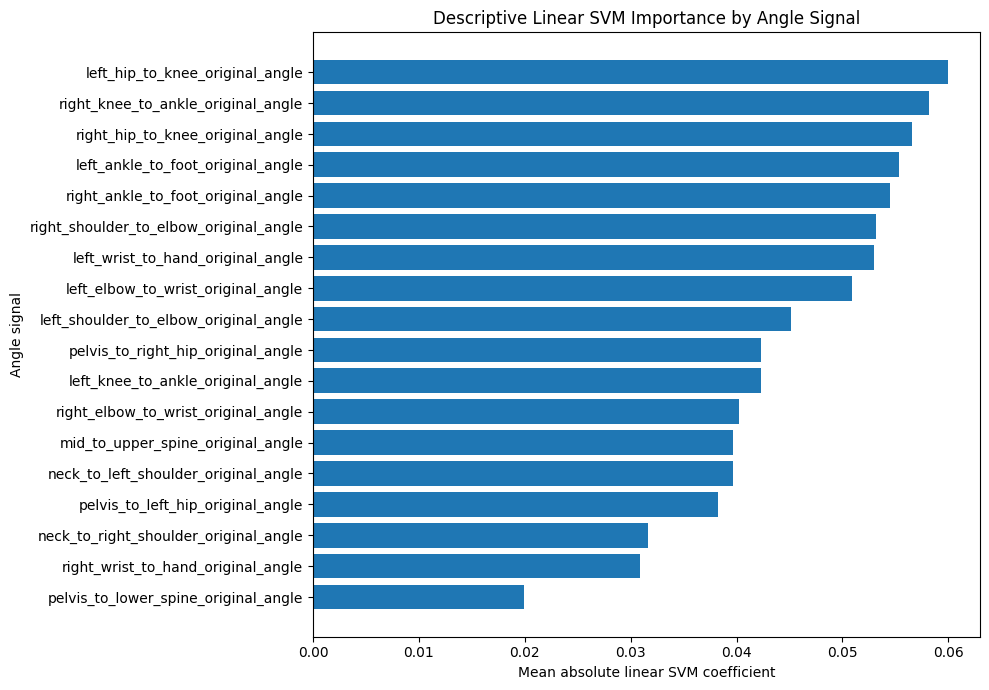

In [39]:
# CELL 39 — Plot descriptive signal importance

import matplotlib.pyplot as plt

plot_df = (
    signal_importance_df
    .sort_values("mean_weight")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["signal"],
    plot_df["mean_weight"]
)

plt.xlabel("Mean absolute linear SVM coefficient")
plt.ylabel("Angle signal")

plt.title(
    "Descriptive Linear SVM Importance by Angle Signal"
)

plt.tight_layout()
plt.show()

Descriptive analysis of the standardized linear SVM coefficients indicated that discriminative information was distributed across multiple body segments. Several lower-limb signals, particularly hip-to-knee, knee-to-ankle, and ankle-to-foot angles, exhibited relatively large coefficient magnitudes, while upper-limb signals also contributed substantially.

People in this dataset have sufficiently different and repeatable gait/posture angle patterns that a linear SVM can identify them across separate walking recordings with high accuracy.

In [40]:
# CELL 40 — Define variability/range-only features

dynamic_feature_cols = [
    col for col in feature_cols
    if col.endswith("__std") or col.endswith("__range")
]

print("Total original features:", len(feature_cols))
print("Dynamic features:", len(dynamic_feature_cols))

for i, col in enumerate(dynamic_feature_cols, 1):
    print(f"{i:02d}. {col}")

assert len(dynamic_feature_cols) == 36

print("\n✓ 36 std/range features selected.")

Total original features: 91
Dynamic features: 36
01. left_ankle_to_foot_original_angle__std
02. left_ankle_to_foot_original_angle__range
03. left_elbow_to_wrist_original_angle__std
04. left_elbow_to_wrist_original_angle__range
05. left_hip_to_knee_original_angle__std
06. left_hip_to_knee_original_angle__range
07. left_knee_to_ankle_original_angle__std
08. left_knee_to_ankle_original_angle__range
09. left_shoulder_to_elbow_original_angle__std
10. left_shoulder_to_elbow_original_angle__range
11. left_wrist_to_hand_original_angle__std
12. left_wrist_to_hand_original_angle__range
13. mid_to_upper_spine_original_angle__std
14. mid_to_upper_spine_original_angle__range
15. neck_to_left_shoulder_original_angle__std
16. neck_to_left_shoulder_original_angle__range
17. neck_to_right_shoulder_original_angle__std
18. neck_to_right_shoulder_original_angle__range
19. pelvis_to_left_hip_original_angle__std
20. pelvis_to_left_hip_original_angle__range
21. pelvis_to_lower_spine_original_angle__std
22. p

In [41]:
# FIX — Recreate exhaustive trial combinations

import itertools

trials_by_person = {
    "Buddhini": [1, 2, 3, 4, 7, 9],
    "Harshika": [1, 2, 3, 4, 5],
    "Muthuni": [1, 2, 3],
    "Nadeera": [1, 2, 3, 4],
    "Thenuri": [1, 2, 3, 4]
}

persons = sorted(trials_by_person.keys())

trial_lists = [
    trials_by_person[person]
    for person in persons
]

exhaustive_combinations = list(
    itertools.product(*trial_lists)
)

print("Persons:", persons)
print("Number of exhaustive combinations:", len(exhaustive_combinations))
print("First combination:", exhaustive_combinations[0])

Persons: ['Buddhini', 'Harshika', 'Muthuni', 'Nadeera', 'Thenuri']
Number of exhaustive combinations: 1440
First combination: (1, 1, 1, 1, 1)


In [42]:
# CELL 41 — Exhaustive evaluation using only std + range features

dynamic_results = []
dynamic_trial_predictions = []

for split_id, heldout_trials in enumerate(
    exhaustive_combinations,
    start=1
):
    test_mask = np.zeros(len(df), dtype=bool)

    for person, trial in zip(persons, heldout_trials):
        test_mask |= (
            (df["person"] == person) &
            (df["trial"] == trial)
        ).to_numpy()

    train_df = df.loc[~test_mask].copy()
    test_df  = df.loc[test_mask].copy()

    X_train = train_df[dynamic_feature_cols]
    y_train = train_df["person"]

    X_test = test_df[dynamic_feature_cols]
    y_test = test_df["person"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="linear",
            C=1.0,
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    dynamic_results.append({
        "split": split_id,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_test, y_pred
        ),
        "macro_f1": f1_score(
            y_test,
            y_pred,
            average="macro"
        )
    })

    pred_df = test_df[
        ["person", "trial", "group_id"]
    ].copy()

    pred_df["predicted_person"] = y_pred

    for (person, trial, group_id), group in pred_df.groupby(
        ["person", "trial", "group_id"]
    ):
        vote_counts = group["predicted_person"].value_counts()

        predicted_person = vote_counts.index[0]

        dynamic_trial_predictions.append({
            "split": split_id,
            "person": person,
            "trial": trial,
            "group_id": group_id,
            "predicted_person": predicted_person,
            "correct": predicted_person == person
        })


dynamic_results_df = pd.DataFrame(dynamic_results)

print("36-FEATURE STD/RANGE MODEL")
print("-" * 45)

print(
    dynamic_results_df[
        ["accuracy", "balanced_accuracy", "macro_f1"]
    ].describe().round(4)
)

36-FEATURE STD/RANGE MODEL
---------------------------------------------
        accuracy  balanced_accuracy   macro_f1
count  1440.0000          1440.0000  1440.0000
mean      0.8450             0.8377     0.8202
std       0.0641             0.0669     0.0667
min       0.6531             0.6268     0.6258
25%       0.8016             0.8001     0.7782
50%       0.8365             0.8395     0.8196
75%       0.8989             0.8843     0.8635
max       0.9888             0.9864     0.9834


In [43]:
# CELL 42 — Compare 91 vs 90 vs 36 features

model_comparison = pd.DataFrame({
    "91 features\n(angle + duration)": [
        exhaustive_results_df["accuracy"].mean(),
        exhaustive_results_df["balanced_accuracy"].mean(),
        exhaustive_results_df["macro_f1"].mean()
    ],

    "90 angle features\n(no duration)": [
        no_duration_results_df["accuracy"].mean(),
        no_duration_results_df["balanced_accuracy"].mean(),
        no_duration_results_df["macro_f1"].mean()
    ],

    "36 std/range features": [
        dynamic_results_df["accuracy"].mean(),
        dynamic_results_df["balanced_accuracy"].mean(),
        dynamic_results_df["macro_f1"].mean()
    ]
}, index=[
    "Accuracy",
    "Balanced accuracy",
    "Macro F1"
])

display(
    (model_comparison * 100).round(2)
)

,91 features\n(angle + duration),90 angle features\n(no duration),36 std/range features
Accuracy,96.36,95.89,84.50
Balanced accuracy,95.04,94.58,83.77
Macro F1,94.82,94.33,82.02


First, duration contributes very little. Removing it reduced accuracy from 96.36% to 95.89%, only 0.47 percentage points. So the model isn't mainly identifying people because one person walks faster or has longer cycles.
Second, when we removed mean, min, and max and retained only std and range, performance dropped from 95.89% → 84.50%.

That's a substantial 11.39 percentage-point reduction.
So the absolute angle-related statistics contain a lot of useful person-specific information.
But there's another important result: 84.5% is still quite high for five classes. Random guessing among five equally likely people would be around 20%.
Therefore, std and range alone still contain considerable person-discriminative information.

In simple terms:
The classifier appears to identify people using both their characteristic angular/postural levels and how much those angles vary during a gait cycle.



In [44]:
# CELL 43 — Define mean/min/max angle features

level_feature_cols = [
    col for col in feature_cols
    if (
        col.endswith("__mean")
        or col.endswith("__min")
        or col.endswith("__max")
    )
]

print("Level/extreme features:", len(level_feature_cols))

for i, col in enumerate(level_feature_cols, 1):
    print(f"{i:02d}. {col}")

assert len(level_feature_cols) == 54

print("\n✓ 54 mean/min/max features selected.")

Level/extreme features: 54
01. left_ankle_to_foot_original_angle__mean
02. left_ankle_to_foot_original_angle__min
03. left_ankle_to_foot_original_angle__max
04. left_elbow_to_wrist_original_angle__mean
05. left_elbow_to_wrist_original_angle__min
06. left_elbow_to_wrist_original_angle__max
07. left_hip_to_knee_original_angle__mean
08. left_hip_to_knee_original_angle__min
09. left_hip_to_knee_original_angle__max
10. left_knee_to_ankle_original_angle__mean
11. left_knee_to_ankle_original_angle__min
12. left_knee_to_ankle_original_angle__max
13. left_shoulder_to_elbow_original_angle__mean
14. left_shoulder_to_elbow_original_angle__min
15. left_shoulder_to_elbow_original_angle__max
16. left_wrist_to_hand_original_angle__mean
17. left_wrist_to_hand_original_angle__min
18. left_wrist_to_hand_original_angle__max
19. mid_to_upper_spine_original_angle__mean
20. mid_to_upper_spine_original_angle__min
21. mid_to_upper_spine_original_angle__max
22. neck_to_left_shoulder_original_angle__mean
23. nec

In [45]:
# CELL 44 — Exhaustive evaluation using mean/min/max only

level_results = []
level_trial_predictions = []

for split_id, heldout_trials in enumerate(
    exhaustive_combinations,
    start=1
):
    test_mask = np.zeros(len(df), dtype=bool)

    for person, trial in zip(persons, heldout_trials):
        test_mask |= (
            (df["person"] == person) &
            (df["trial"] == trial)
        ).to_numpy()

    train_df = df.loc[~test_mask].copy()
    test_df = df.loc[test_mask].copy()

    X_train = train_df[level_feature_cols]
    y_train = train_df["person"]

    X_test = test_df[level_feature_cols]
    y_test = test_df["person"]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="linear",
            C=1.0,
            class_weight="balanced"
        ))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    level_results.append({
        "split": split_id,
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy":
            balanced_accuracy_score(y_test, y_pred),
        "macro_f1":
            f1_score(y_test, y_pred, average="macro")
    })

    pred_df = test_df[
        ["person", "trial", "group_id"]
    ].copy()

    pred_df["predicted_person"] = y_pred

    for (person, trial, group_id), group in pred_df.groupby(
        ["person", "trial", "group_id"]
    ):
        predicted_person = (
            group["predicted_person"]
            .value_counts()
            .index[0]
        )

        level_trial_predictions.append({
            "split": split_id,
            "person": person,
            "trial": trial,
            "group_id": group_id,
            "predicted_person": predicted_person,
            "correct": predicted_person == person
        })


level_results_df = pd.DataFrame(level_results)

print("54-FEATURE MEAN/MIN/MAX MODEL")
print("-" * 45)

display(
    level_results_df[
        ["accuracy", "balanced_accuracy", "macro_f1"]
    ].describe().round(4)
)

54-FEATURE MEAN/MIN/MAX MODEL
---------------------------------------------


,accuracy,balanced_accuracy,macro_f1
count,1440.0000,1440.0000,1440.0000
mean,0.9515,0.9372,0.9343
std,0.0300,0.0417,0.0416
min,0.8317,0.7886,0.7685
25%,0.9374,0.9156,0.9112
50%,0.9560,0.9453,0.9421
75%,0.9723,0.9600,0.9635
max,1.0000,1.0000,1.0000


In [46]:
# CELL 45 — Final feature ablation comparison

ablation_comparison = pd.DataFrame({
    "91: all + duration": [
        exhaustive_results_df["accuracy"].mean(),
        exhaustive_results_df["balanced_accuracy"].mean(),
        exhaustive_results_df["macro_f1"].mean()
    ],

    "90: all angles": [
        no_duration_results_df["accuracy"].mean(),
        no_duration_results_df["balanced_accuracy"].mean(),
        no_duration_results_df["macro_f1"].mean()
    ],

    "54: mean/min/max": [
        level_results_df["accuracy"].mean(),
        level_results_df["balanced_accuracy"].mean(),
        level_results_df["macro_f1"].mean()
    ],

    "36: std/range": [
        dynamic_results_df["accuracy"].mean(),
        dynamic_results_df["balanced_accuracy"].mean(),
        dynamic_results_df["macro_f1"].mean()
    ]
}, index=[
    "Accuracy",
    "Balanced accuracy",
    "Macro F1"
])

display((ablation_comparison * 100).round(2))

,91: all + duration,90: all angles,54: mean/min/max,36: std/range
Accuracy,96.36,95.89,95.15,84.50
Balanced accuracy,95.04,94.58,93.72,83.77
Macro F1,94.82,94.33,93.43,82.02


The main finding is that mean/min/max features carry most of the discriminative information. With only those 54 features, accuracy remains 95.15%, just 0.74 percentage points below the complete 90-angle-feature model.

However, variability is also informative. Using only std and range still gives 84.50% accuracy, so variation within a gait cycle contains person-specific information too.

The full angle representation performs best because it combines both types of information:
absolute/angular characteristics + within-cycle variability → 95.89%

Adding cycle duration raises this only slightly to 96.36%, so duration is not driving the result.

experiments indicate that the classifier primarily distinguishes participants from their angle characteristics, especially mean values and extrema, while dynamic variability provides additional complementary information.

And importantly, these results came from trial-grouped evaluation rather than randomly mixing cycles from the same recording between training and testing.


Using exhaustive trial-grouped evaluation across five participants, the linear SVM achieved a mean cycle-level accuracy of 96.36%, balanced accuracy of 95.04%, and macro-F1 of 94.82%.

USEFUL FINDINGS:

Trial separation works: entire trials are kept together, preventing direct cycle leakage between train and test.

Cross-trial identification is strong: the linear SVM achieves around 95–96% cycle-level performance.
Duration isn't responsible: removing duration barely changes performance.

Angle levels aren't the whole story: mean/min/max are very strong, but std/range alone still achieve 84.5%.

In [47]:
exhaustive_results_df.to_csv(
    RESULTS_DIR / "exhaustive_svm_results.csv",
    index=False
)